In [1]:
using JuMP
using HiGHS
using Plots

In [2]:
model = Model(HiGHS.Optimizer)

A JuMP Model
├ solver: HiGHS
├ objective_sense: FEASIBILITY_SENSE
├ num_variables: 0
├ num_constraints: 0
└ Names registered in the model: none

In [3]:
@variable(model,0<= basic <= 50)

basic

In [4]:
@variable(model, 0 <= deluxe <= 35)

deluxe

In [5]:
@constraint(model,  0.6basic + 1.5deluxe <= 63)

0.6 basic + 1.5 deluxe ≤ 63

In [6]:
@constraint(model, 5basic + 5deluxe <= 300)

5 basic + 5 deluxe ≤ 300

In [7]:
@objective(model, Max, 200basic + 350deluxe)

200 basic + 350 deluxe

In [8]:
print(model)

In [9]:
optimize!(model)

Running HiGHS 1.15.1 (git hash: 04024d701f): Copyright (c) 2026 under MIT licence terms
Includes third-party software components, see THIRD_PARTY_NOTICES.md for full details
Using BLAS: Apple Accelerate 
LP has 2 rows; 2 cols; 4 nonzeros
Coefficient ranges:
  Matrix  [6e-01, 5e+00]
  Cost    [2e+02, 4e+02]
  Bound   [4e+01, 5e+01]
  RHS     [6e+01, 3e+02]
Presolving model
2 rows, 2 cols, 4 nonzeros 0s
2 rows, 2 cols, 4 nonzeros 0s
Presolve reductions: rows 2(-0); columns 2(-0); nonzeros 4(-0) - Not reduced
Problem not reduced by presolve: solving the LP
Using dual simplex solver
  Iteration        Objective     Infeasibilities num(sum)
          0     0.0000000000e+00 Ph1: 0(0) 0.0s
          2     1.6500000000e+04 Pr: 0(0) 0.0s

Model status        : Optimal
Simplex   iterations: 2
Objective value     :  1.6500000000e+04
P-D objective error :  0.0000000000e+00
HiGHS run time      :          0.00


In [10]:
value(basic), value(deluxe), objective_value(model)

(30.0, 30.0, 16500.0)

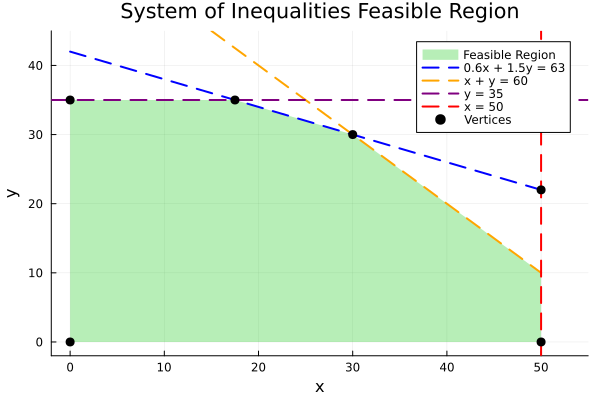

In [11]:
using Plots

# 1. Define x-domain strictly within 0 <= x <= 50
x = 0:0.5:50

# 2. Define upper boundary functions
y1(x) = -0.4 .* x .+ 42    # From 0.6x + 1.5y <= 63
y2(x) = -x .+ 60           # From x + y <= 60
y3(x) = 35.0              # From y <= 35 cap

# 3. Compute combined feasible upper bound at each x
y_feasible = min.(y1(x), y2(x), y3(x))

# 4. Plot the Feasible Region (FIXED: linecolor = :transparent)
plot(x, y_feasible, 
     fillrange = 0,               
     fillalpha = 0.35, 
     fillcolor = :limegreen, 
     linecolor = :transparent,     # <-- FIX IS HERE
     label = "Feasible Region",
     xlabel = "x", 
     ylabel = "y", 
     title = "System of Inequalities Feasible Region",
     xlims = (-2, 55), 
     ylims = (-2, 45),
     legend = :topright)

# 5. Overlay individual boundary lines for clarity
plot!(x, y1(x), linestyle = :dash, color = :blue,   linewidth = 2, label = "0.6x + 1.5y = 63")
plot!(x, y2(x), linestyle = :dash, color = :orange, linewidth = 2, label = "x + y = 60")
hline!([35],   linestyle = :dash, color = :purple, linewidth = 2, label = "y = 35")
vline!([50],   linestyle = :dash, color = :red,    linewidth = 2, label = "x = 50")

# 6. Highlight key corner (vertex) points
scatter!([0, 0, 17.5, 30, 50, 50], [0, 35, 35, 30, 22, 0], 
         color = :black, markersize = 5, label = "Vertices")